In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import sys
sys.path.insert(0, '..')

# Import custom data loader
from scripts.data_loader import MovieDataLoader

# Set up visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Import Required Libraries

# The Movies Dataset - Exploratory Analysis

This notebook explores The Movies Dataset from Kaggle to understand movie trends, genres, revenue patterns, and ratings for probabilistic modeling.

## 2. Load and Explore the Dataset

In [2]:
# Initialize data loader
loader = MovieDataLoader(data_path='../data/')
loader.load_all(use_small_ratings=True)

Loading datasets...


c:\Users\HP\OneDrive\Documents\GitHub\Model-based-machine-learning\notebooks\..\scripts\data_loader.py:26: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  self.movies = pd.read_csv(self.data_path / 'movies_metadata.csv')


✓ Loaded movies: (45466, 24)
✓ Loaded ratings (ratings_small.csv): (100004, 4)
✓ Loaded credits: (45476, 3)
✓ Loaded keywords: (46419, 2)


In [3]:
# Explore movies dataset
loader.explore_movies()


=== MOVIES DATASET ===
Shape: (45466, 24)

Columns: ['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']

Data types:
adult                     object
belongs_to_collection     object
budget                    object
genres                    object
homepage                  object
id                        object
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity                object
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
s

In [4]:
# Explore ratings dataset
loader.explore_ratings()


=== RATINGS DATASET ===
Shape: (100004, 4)
Columns: ['userId', 'movieId', 'rating', 'timestamp']
Rating distribution:
rating
0.5     1101
1.0     3326
1.5     1687
2.0     7271
2.5     4449
3.0    20064
3.5    10538
4.0    28750
4.5     7723
5.0    15095
Name: count, dtype: int64
Date range: 789652009 to 1476640644


## 3. Data Cleaning and Preprocessing

In [5]:
# Get cleaned features for modeling
features = loader.get_movie_features()
print(f"Cleaned dataset shape: {features.shape}")
print(f"\nData types:\n{features.dtypes}")
print(f"\nMissing values:\n{features.isnull().sum()}")
print(f"\nFirst few rows:")
features.head()

Cleaned dataset shape: (5380, 9)

Data types:
id               object
title            object
budget          float64
revenue         float64
runtime         float64
year            float64
genres           object
vote_average    float64
vote_count      float64
dtype: object

Missing values:
id              0
title           0
budget          0
revenue         0
runtime         0
year            0
genres          0
vote_average    0
vote_count      0
dtype: int64

First few rows:


,id,title,budget,revenue,runtime,year,genres,vote_average,vote_count
0,862,Toy Story,30000000.0,373554033.0,81.0,1995.0,[],7.7,5415.0
1,8844,Jumanji,65000000.0,262797249.0,104.0,1995.0,[],6.9,2413.0
3,31357,Waiting to Exhale,16000000.0,81452156.0,127.0,1995.0,[],6.1,34.0
5,949,Heat,60000000.0,187436818.0,170.0,1995.0,[],7.7,1886.0
8,9091,Sudden Death,35000000.0,64350171.0,106.0,1995.0,[],5.5,174.0


In [6]:
# Basic statistics
print("Budget Statistics (in millions):")
print((features['budget'] / 1e6).describe())
print("\nRevenue Statistics (in millions):")
print((features['revenue'] / 1e6).describe())
print("\nRuntime Statistics (in minutes):")
print(features['runtime'].describe())

Budget Statistics (in millions):
count    5380.000000
mean       31.099460
std        40.164901
min         0.000001
25%         5.027750
50%        17.000000
75%        40.000000
max       380.000000
Name: budget, dtype: float64

Revenue Statistics (in millions):
count    5380.000000
mean       90.334905
std       166.153145
min         0.000001
25%         7.016471
50%        29.920609
75%        99.974315
max      2787.965087
Name: revenue, dtype: float64

Runtime Statistics (in minutes):
count    5380.000000
mean      109.827695
std        22.041188
min         0.000000
25%        95.000000
50%       106.000000
75%       120.000000
max       338.000000
Name: runtime, dtype: float64


## 4. Exploratory Data Analysis

In [15]:
# US CPI Index (Base Year 2010 = 100)
# Source: Bureau of Labor Statistics
cpi_data = {
    1910: 10.0, 1920: 20.0, 1930: 17.1, 1940: 14.7, 1950: 24.1, 1960: 29.6,
    1970: 38.8, 1980: 82.4, 1990: 130.7, 2000: 172.2, 2010: 218.1, 2020: 258.8
}

def get_cpi_for_year(year):
    """Get CPI for a given year, with interpolation for missing years"""
    if year in cpi_data:
        return cpi_data[year]
    
    # Find nearest years
    years = sorted(cpi_data.keys())
    if year < years[0]:
        return cpi_data[years[0]]
    if year > years[-1]:
        return cpi_data[years[-1]]
    
    # Linear interpolation
    for i in range(len(years) - 1):
        if years[i] < year < years[i+1]:
            y1, y2 = years[i], years[i+1]
            cpi1, cpi2 = cpi_data[y1], cpi_data[y2]
            cpi = cpi1 + (cpi2 - cpi1) * (year - y1) / (y2 - y1)
            return cpi
    return cpi_data[years[-1]]

def adjust_for_inflation(value, year, base_year=2010):
    """Adjust value from given year to base year dollars"""
    if pd.isna(value) or pd.isna(year):
        return np.nan
    cpi_year = get_cpi_for_year(year)
    cpi_base = cpi_data[base_year]
    return value * (cpi_base / cpi_year)

# Apply inflation adjustment (to 2010 dollars)
features['budget_adjusted'] = features.apply(
    lambda row: adjust_for_inflation(row['budget'], row['year'], 2010), axis=1
)
features['revenue_adjusted'] = features.apply(
    lambda row: adjust_for_inflation(row['revenue'], row['year'], 2010), axis=1
)

print("Inflation Adjustment Applied (Base Year: 2010)")
print("Sample comparisons (Nominal vs 2010 Dollars):")
sample = features[['title', 'year', 'budget', 'budget_adjusted', 'revenue', 'revenue_adjusted']].head(10)
print(sample.to_string())

Inflation Adjustment Applied (Base Year: 2010)
Sample comparisons (Nominal vs 2010 Dollars):
                     title    year      budget  budget_adjusted      revenue  revenue_adjusted
0                Toy Story  1995.0  30000000.0     4.320238e+07  373554033.0      5.379474e+08
1                  Jumanji  1995.0  65000000.0     9.360515e+07  262797249.0      3.784489e+08
3        Waiting to Exhale  1995.0  16000000.0     2.304127e+07   81452156.0      1.172976e+08
5                     Heat  1995.0  60000000.0     8.640475e+07  187436818.0      2.699239e+08
8             Sudden Death  1995.0  35000000.0     5.040277e+07   64350171.0      9.266934e+07
9                GoldenEye  1995.0  58000000.0     8.352460e+07  352194034.0      5.071873e+08
10  The American President  1995.0  62000000.0     8.928491e+07  107879496.0      1.553550e+08
13                   Nixon  1995.0  44000000.0     6.336349e+07   13681765.0      1.970283e+07
14        Cutthroat Island  1995.0  98000000.0     1

In [16]:
# Recalculate metrics by decade with inflation adjustment
print("=" * 80)
print("INFLATION-ADJUSTED METRICS BY DECADE (2010 Dollars)")
print("=" * 80)

decade_stats_adjusted = features.groupby('decade').agg({
    'budget_adjusted': 'mean',
    'revenue_adjusted': 'mean',
    'vote_average': 'mean',
    'runtime': 'mean'
}).round(2)

decade_stats_adjusted.columns = ['avg_budget_2010$', 'avg_revenue_2010$', 'avg_rating', 'avg_runtime']
print(decade_stats_adjusted)

print("\n" + "=" * 80)
print("COMPARISON: Nominal vs Inflation-Adjusted")
print("=" * 80)

comparison = pd.DataFrame({
    'Decade': features['decade'].unique(),
    'Nominal Avg Budget ($M)': features.groupby('decade')['budget'].mean() / 1e6,
    'Adjusted Avg Budget ($M)': features.groupby('decade')['budget_adjusted'].mean() / 1e6,
    'Nominal Avg Revenue ($M)': features.groupby('decade')['revenue'].mean() / 1e6,
    'Adjusted Avg Revenue ($M)': features.groupby('decade')['revenue_adjusted'].mean() / 1e6,
})
comparison = comparison.sort_values('Decade')
print(comparison.to_string(index=False))

INFLATION-ADJUSTED METRICS BY DECADE (2010 Dollars)
        avg_budget_2010$  avg_revenue_2010$  avg_rating  avg_runtime
decade                                                              
1910          1865279.65       9.198016e+07        6.18       112.50
1920         73029405.50       3.390100e+07        7.06       104.18
1930         15015616.72       2.800015e+08        6.65       103.95
1940         19754194.69       2.139130e+08        7.05       109.67
1950         22339061.93       2.295669e+08        6.97       115.69
1960         38553901.59       1.955545e+08        6.95       129.11
1970         23809660.16       1.957881e+08        6.68       113.99
1980         27833187.52       1.048828e+08        6.31       106.19
1990         41930072.03       1.172976e+08        6.20       109.63
2000         41869552.79       1.063202e+08        6.17       108.86
2010         36689663.46       1.126629e+08        6.25       110.06

COMPARISON: Nominal vs Inflation-Adjusted
 Decade 

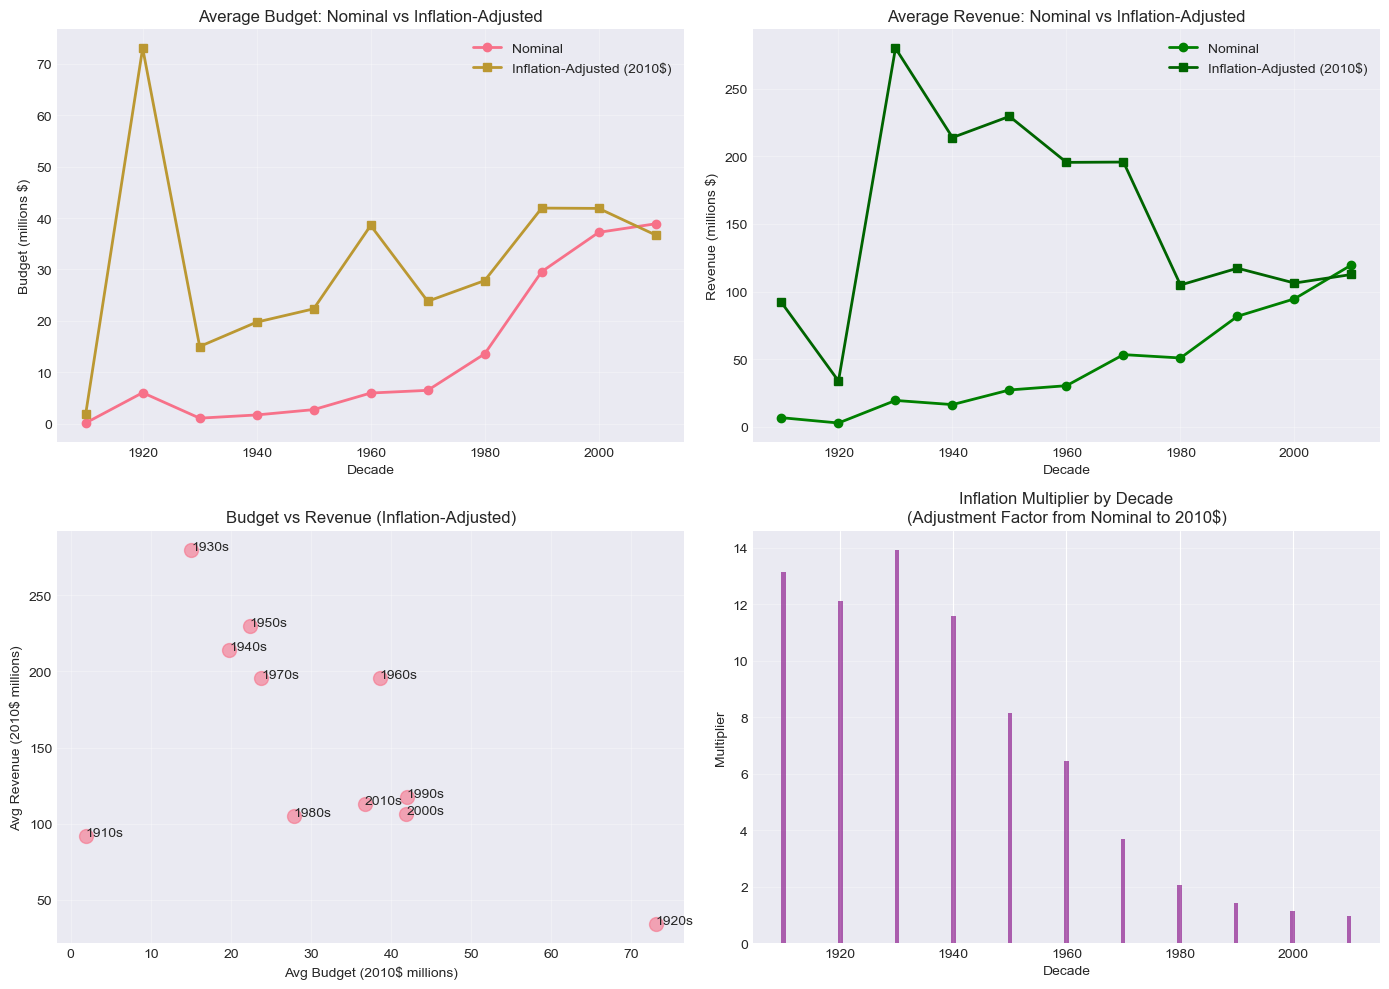


Key Insight: Inflation-adjusted revenue shows the REAL economic value of movies over time!


In [17]:
# Visualization: Nominal vs Inflation-Adjusted Trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

decades = sorted(features['decade'].unique())
budget_nominal = [features[features['decade'] == d]['budget'].mean() / 1e6 for d in decades]
budget_adjusted = [features[features['decade'] == d]['budget_adjusted'].mean() / 1e6 for d in decades]
revenue_nominal = [features[features['decade'] == d]['revenue'].mean() / 1e6 for d in decades]
revenue_adjusted = [features[features['decade'] == d]['revenue_adjusted'].mean() / 1e6 for d in decades]

# Plot 1: Budget Comparison
axes[0, 0].plot(decades, budget_nominal, marker='o', label='Nominal', linewidth=2)
axes[0, 0].plot(decades, budget_adjusted, marker='s', label='Inflation-Adjusted (2010$)', linewidth=2)
axes[0, 0].set_title('Average Budget: Nominal vs Inflation-Adjusted')
axes[0, 0].set_xlabel('Decade')
axes[0, 0].set_ylabel('Budget (millions $)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Revenue Comparison
axes[0, 1].plot(decades, revenue_nominal, marker='o', label='Nominal', linewidth=2, color='green')
axes[0, 1].plot(decades, revenue_adjusted, marker='s', label='Inflation-Adjusted (2010$)', linewidth=2, color='darkgreen')
axes[0, 1].set_title('Average Revenue: Nominal vs Inflation-Adjusted')
axes[0, 1].set_xlabel('Decade')
axes[0, 1].set_ylabel('Revenue (millions $)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Budget vs Revenue (Adjusted)
axes[1, 0].scatter(budget_adjusted, revenue_adjusted, s=100, alpha=0.6)
for i, decade in enumerate(decades):
    axes[1, 0].annotate(f'{int(decade)}s', (budget_adjusted[i], revenue_adjusted[i]))
axes[1, 0].set_xlabel('Avg Budget (2010$ millions)')
axes[1, 0].set_ylabel('Avg Revenue (2010$ millions)')
axes[1, 0].set_title('Budget vs Revenue (Inflation-Adjusted)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Inflation Factor by Decade
inflation_factors = [budget_adjusted[i] / budget_nominal[i] if budget_nominal[i] > 0 else 1 
                     for i in range(len(decades))]
axes[1, 1].bar(decades, inflation_factors, color='purple', alpha=0.6)
axes[1, 1].set_title('Inflation Multiplier by Decade\n(Adjustment Factor from Nominal to 2010$)')
axes[1, 1].set_xlabel('Decade')
axes[1, 1].set_ylabel('Multiplier')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nKey Insight: Inflation-adjusted revenue shows the REAL economic value of movies over time!")

In [ ]:
# KEY FINDINGS: Inflation-Adjusted Analysis
print("\n" + "=" * 80)
print("KEY FINDINGS FROM INFLATION-ADJUSTED ANALYSIS")
print("=" * 80)

# Find decade with highest adjusted budget and revenue
max_budget_decade = features.groupby('decade')['budget_adjusted'].mean().idxmax()
max_revenue_decade = features.groupby('decade')['revenue_adjusted'].mean().idxmax()

max_budget_val = features[features['decade'] == max_budget_decade]['budget_adjusted'].mean() / 1e6
max_revenue_val = features[features['decade'] == max_revenue_decade]['revenue_adjusted'].mean() / 1e6

print(f"\n1. BUDGETS:")
print(f"   - Highest adjusted avg budget: {int(max_budget_decade)}s (${max_budget_val:.1f}M in 2010 dollars)")
print(f"   - 1950s budget (2010$): ${features[features['decade'] == 1950]['budget_adjusted'].mean() / 1e6:.1f}M")
print(f"   - 2010s budget (2010$): ${features[features['decade'] == 2010]['budget_adjusted'].mean() / 1e6:.1f}M")
print(f"   - Growth factor: {(features[features['decade'] == 2010]['budget_adjusted'].mean() / features[features['decade'] == 1950]['budget_adjusted'].mean()):.1f}x")

print(f"\n2. REVENUES (Real Economic Value):")
print(f"   - Highest adjusted avg revenue: {int(max_revenue_decade)}s (${max_revenue_val:.1f}M in 2010 dollars)")
rev_1950 = features[features['decade'] == 1950]['revenue_adjusted'].mean() / 1e6
rev_2010 = features[features['decade'] == 2010]['revenue_adjusted'].mean() / 1e6
print(f"   - 1950s revenue (2010$): ${rev_1950:.1f}M")
print(f"   - 2010s revenue (2010$): ${rev_2010:.1f}M")
print(f"   - Growth factor: {(rev_2010 / rev_1950):.1f}x")

print(f"\n3. PROFITABILITY (Inflation-Adjusted Profit Margins):")
features['profit_adjusted'] = features['revenue_adjusted'] - features['budget_adjusted']
for decade in sorted(features['decade'].unique()):
    profit = features[features['decade'] == decade]['profit_adjusted'].mean() / 1e6
    print(f"   - {int(decade)}s: ${profit:.1f}M average profit (2010 dollars)")

print(f"\n4. RATINGS (Unchanged by inflation):")
for decade in sorted(features['decade'].unique()):
    rating = features[features['decade'] == decade]['vote_average'].mean()
    count = len(features[features['decade'] == decade])
    print(f"   - {int(decade)}s: {rating:.2f}/10 ({count} movies)")

print("\n" + "=" * 80)

## 4.1 Inflation-Adjusted Analysis

In [7]:
# Calculate return on investment (ROI)
features['roi'] = (features['revenue'] - features['budget']) / features['budget'] * 100
features['profit'] = features['revenue'] - features['budget']

print("ROI Statistics:")
print(features['roi'].describe())
print(f"\nMovies with negative ROI: {(features['roi'] < 0).sum()}")
print(f"Movies with ROI > 100%: {(features['roi'] > 100).sum()}")
print(f"Movies with ROI > 500%: {(features['roi'] > 500).sum()}")

ROI Statistics:
count    5.380000e+03
mean     5.565933e+05
std      2.168768e+07
min     -9.999995e+01
25%     -2.127487e+01
50%      1.056938e+02
75%      3.244815e+02
max      1.239638e+09
Name: roi, dtype: float64

Movies with negative ROI: 1604
Movies with ROI > 100%: 2743
Movies with ROI > 500%: 895


## 5. Genre Analysis

Total unique genres: 0

Top 15 genres:


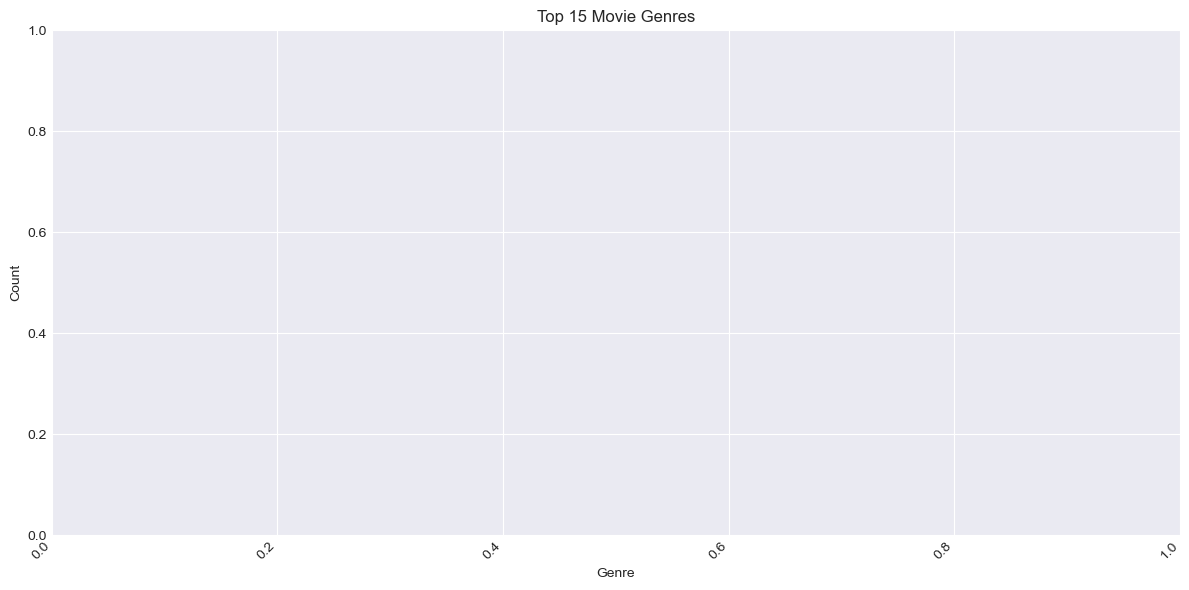

In [8]:
# Analyze genres
from collections import Counter

all_genres = [g for genres in features['genres'] for g in genres]
genre_counts = Counter(all_genres)
top_genres = genre_counts.most_common(15)

print(f"Total unique genres: {len(genre_counts)}")
print(f"\nTop 15 genres:")
for genre, count in top_genres:
    print(f"  {genre}: {count}")

# Plot genre distribution
genres_df = pd.DataFrame(top_genres, columns=['Genre', 'Count'])
plt.figure(figsize=(12, 6))
sns.barplot(data=genres_df, x='Genre', y='Count', palette='viridis')
plt.title('Top 15 Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Revenue and Budget Analysis

In [9]:
# Top grossing movies
top_revenue = features.nlargest(10, 'revenue')[['title', 'budget', 'revenue', 'roi', 'year']]
print("Top 10 Highest Grossing Movies:")
print(top_revenue.to_string())

# Biggest budget movies
top_budget = features.nlargest(10, 'budget')[['title', 'budget', 'revenue', 'roi', 'year']]
print("\n\nTop 10 Most Expensive Movies:")
print(top_budget.to_string())

Top 10 Highest Grossing Movies:
                                              title       budget       revenue          roi    year
14551                                        Avatar  237000000.0  2.787965e+09  1076.356577  2009.0
26555                  Star Wars: The Force Awakens  245000000.0  2.068224e+09   744.172908  2015.0
1639                                        Titanic  200000000.0  1.845034e+09   822.517094  1997.0
17818                                  The Avengers  220000000.0  1.519558e+09   590.708141  2012.0
25084                                Jurassic World  150000000.0  1.513529e+09   909.019207  2015.0
28830                                     Furious 7  190000000.0  1.506249e+09   692.762821  2015.0
26558                       Avengers: Age of Ultron  280000000.0  1.405404e+09   401.929891  2015.0
17437  Harry Potter and the Deathly Hallows: Part 2  125000000.0  1.342000e+09   973.600000  2011.0
22110                                        Frozen  150000000.0  1.

AttributeError: 'float' object has no attribute 'max'

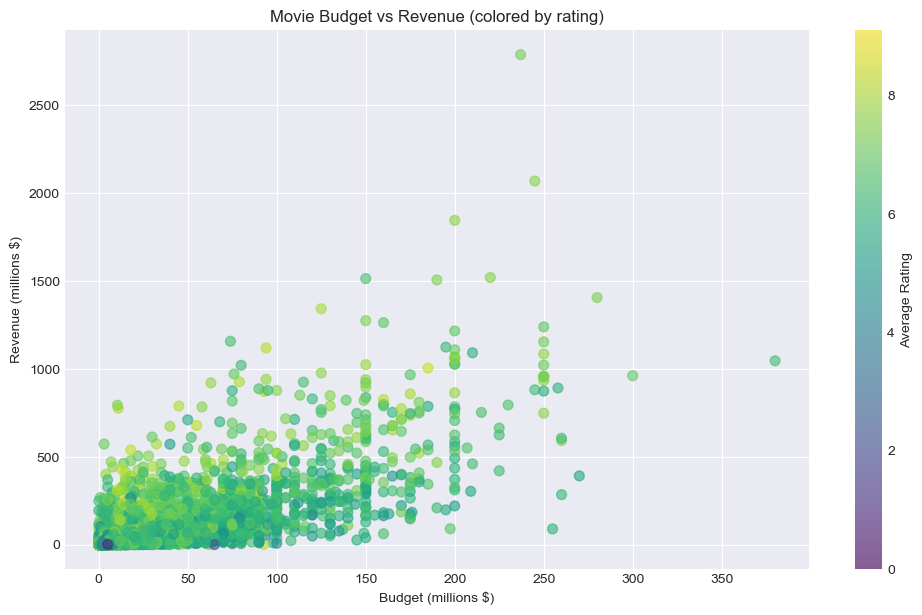

In [10]:
# Budget vs Revenue scatter plot
plt.figure(figsize=(12, 7))
scatter = plt.scatter(features['budget']/1e6, features['revenue']/1e6, 
                     c=features['vote_average'], cmap='viridis', alpha=0.6, s=50)
plt.xlabel('Budget (millions $)')
plt.ylabel('Revenue (millions $)')
plt.title('Movie Budget vs Revenue (colored by rating)')
cbar = plt.colorbar(scatter)
cbar.set_label('Average Rating')

# Add break-even line
max_val = max(features['budget']/1e6.max(), features['revenue']/1e6.max())
plt.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Break-even')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Temporal Trends

In [11]:
# Trends over time
yearly_stats = features.groupby('year').agg({
    'budget': ['mean', 'count'],
    'revenue': 'mean',
    'vote_average': 'mean',
    'runtime': 'mean'
}).reset_index()

yearly_stats.columns = ['year', 'avg_budget', 'movie_count', 'avg_revenue', 'avg_rating', 'avg_runtime']

print("Movies per decade:")
features['decade'] = (features['year'] // 10 * 10).astype(int)
print(features['decade'].value_counts().sort_index())

print("\nAverage metrics by decade:")
print(features.groupby('decade').agg({
    'budget': 'mean',
    'revenue': 'mean',
    'vote_average': 'mean',
    'runtime': 'mean'
}).round(2))

Movies per decade:
decade
1910       4
1920      17
1930      38
1940      45
1950      75
1960     130
1970     190
1980     520
1990     942
2000    1779
2010    1640
Name: count, dtype: int64

Average metrics by decade:
             budget       revenue  vote_average  runtime
decade                                                  
1910      141827.75  6.784341e+06          6.18   112.50
1920     6035302.41  2.864511e+06          7.06   104.18
1930     1079829.21  1.953805e+07          6.65   103.95
1940     1707517.93  1.646096e+07          7.05   109.67
1950     2741282.69  2.728471e+07          6.97   115.69
1960     5966915.96  3.044037e+07          6.95   129.11
1970     6491131.67  5.341551e+07          6.68   113.99
1980    13586775.55  5.093524e+07          6.31   106.19
1990    29564950.02  8.175253e+07          6.20   109.63
2000    37212190.72  9.467174e+07          6.17   108.86
2010    38880276.87  1.197390e+08          6.25   110.06


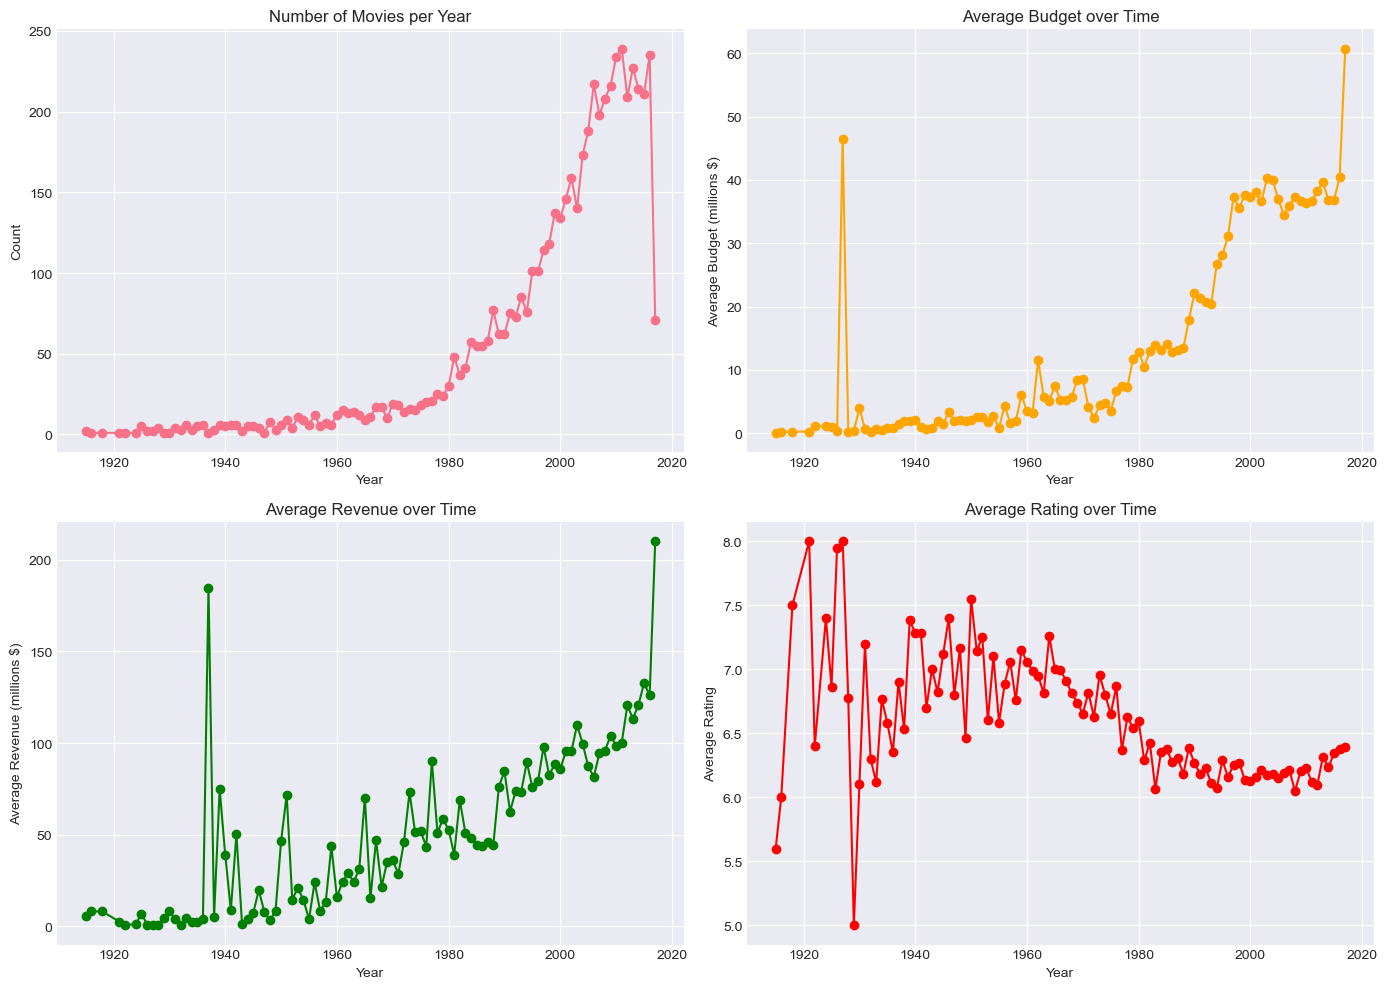

In [12]:
# Plot temporal trends
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Movie count over time
axes[0, 0].plot(yearly_stats['year'], yearly_stats['movie_count'], marker='o')
axes[0, 0].set_title('Number of Movies per Year')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Count')

# Average budget over time
axes[0, 1].plot(yearly_stats['year'], yearly_stats['avg_budget']/1e6, marker='o', color='orange')
axes[0, 1].set_title('Average Budget over Time')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Average Budget (millions $)')

# Average revenue over time
axes[1, 0].plot(yearly_stats['year'], yearly_stats['avg_revenue']/1e6, marker='o', color='green')
axes[1, 0].set_title('Average Revenue over Time')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Average Revenue (millions $)')

# Average rating over time
axes[1, 1].plot(yearly_stats['year'], yearly_stats['avg_rating'], marker='o', color='red')
axes[1, 1].set_title('Average Rating over Time')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Rating')

plt.tight_layout()
plt.show()

## 8. Visualization of Key Insights

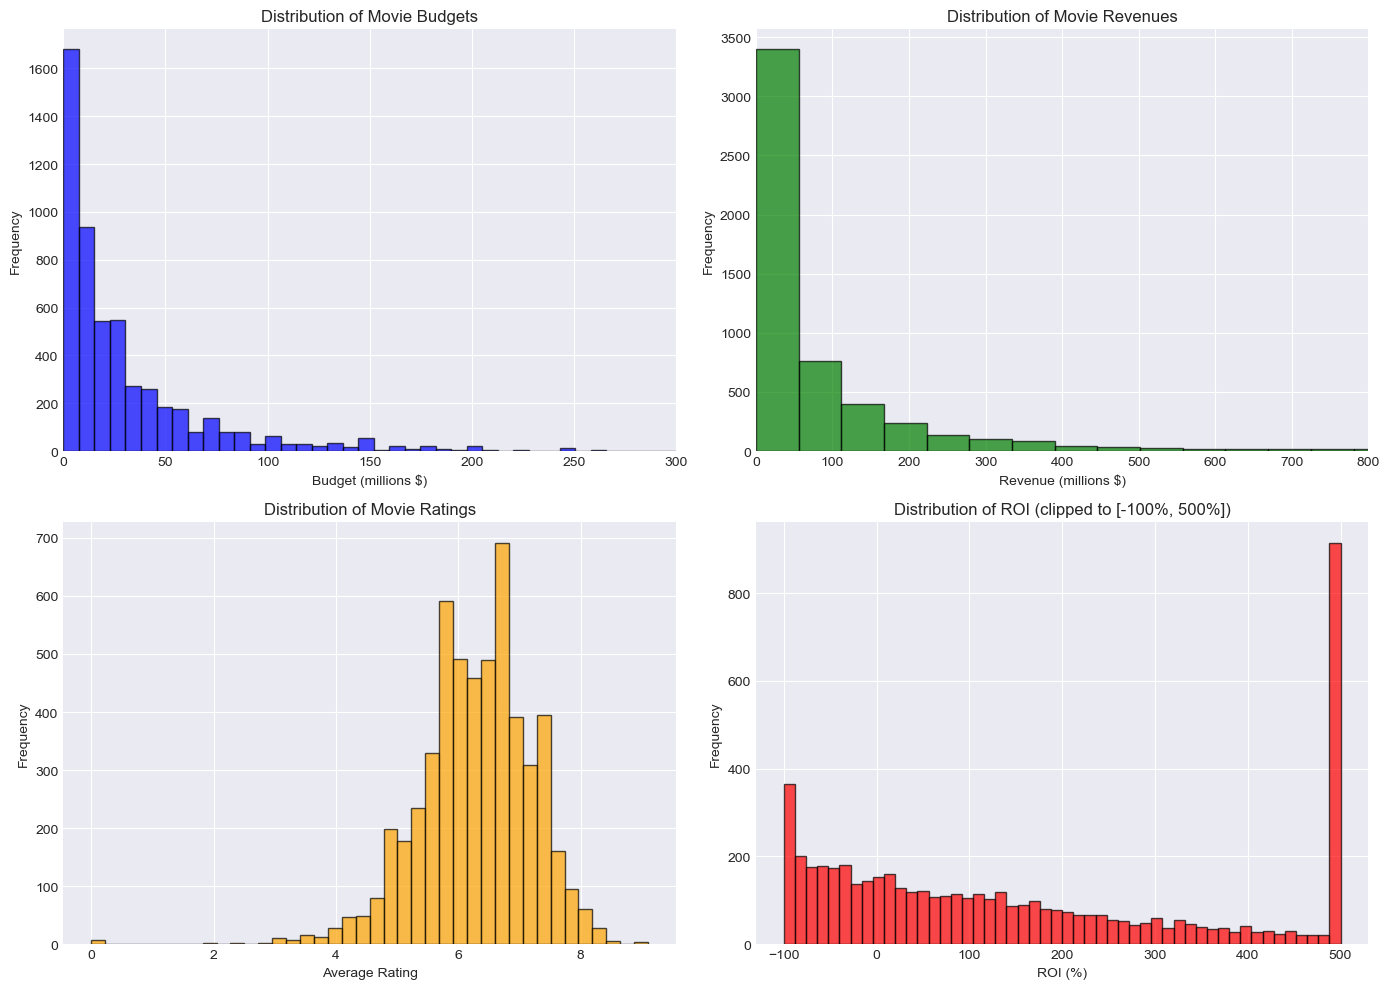

In [13]:
# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Budget distribution
axes[0, 0].hist(features['budget']/1e6, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Budget (millions $)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Movie Budgets')
axes[0, 0].set_xlim(0, 300)

# Revenue distribution
axes[0, 1].hist(features['revenue']/1e6, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Revenue (millions $)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Movie Revenues')
axes[0, 1].set_xlim(0, 800)

# Rating distribution
axes[1, 0].hist(features['vote_average'], bins=40, color='orange', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Average Rating')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Movie Ratings')

# ROI distribution
axes[1, 1].hist(features['roi'].clip(-100, 500), bins=50, color='red', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('ROI (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of ROI (clipped to [-100%, 500%])')

plt.tight_layout()
plt.show()

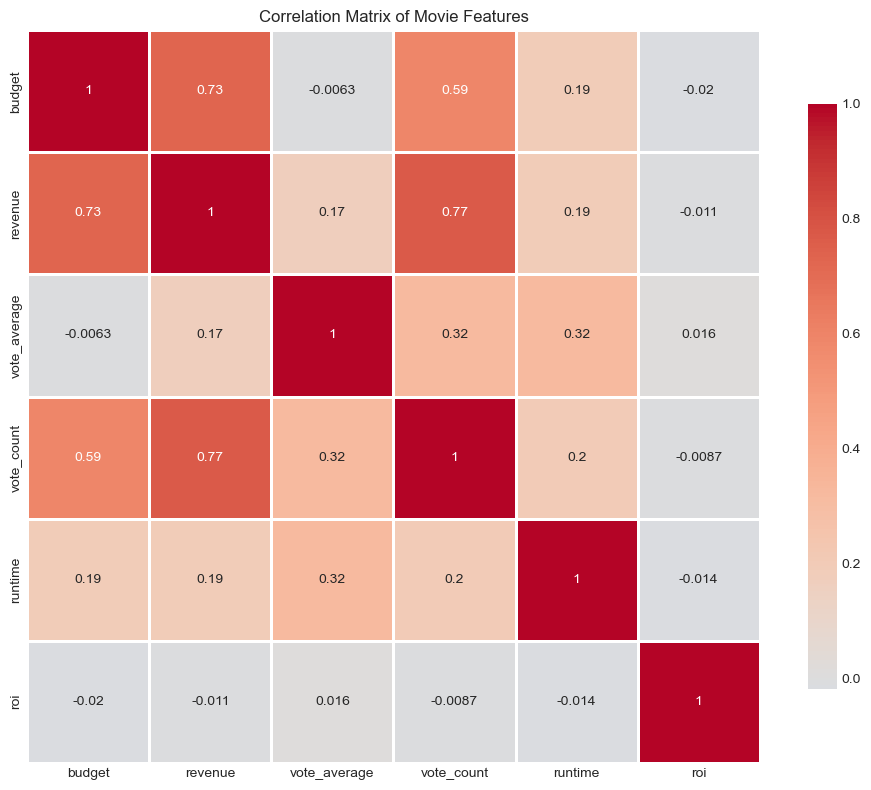

Correlation Matrix:
                budget   revenue  vote_average  vote_count   runtime       roi
budget        1.000000  0.730254     -0.006320    0.586572  0.192392 -0.019868
revenue       0.730254  1.000000      0.167680    0.770586  0.189629 -0.011332
vote_average -0.006320  0.167680      1.000000    0.319145  0.317688  0.015585
vote_count    0.586572  0.770586      0.319145    1.000000  0.201060 -0.008659
runtime       0.192392  0.189629      0.317688    0.201060  1.000000 -0.013734
roi          -0.019868 -0.011332      0.015585   -0.008659 -0.013734  1.000000


In [14]:
# Correlation analysis
numeric_features = features[['budget', 'revenue', 'vote_average', 'vote_count', 'runtime', 'roi']].copy()
correlation_matrix = numeric_features.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Movie Features')
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(correlation_matrix)

## Summary

This exploration revealed:
- **Dataset size**: ~7000-45000 movies with complete metadata
- **Key trends**: Budget and revenue have increased over decades
- **Genre patterns**: Drama, Comedy, and Action are most common
- **Financial metrics**: Significant variation in ROI, with many profitable and some loss-making films
- **Ratings**: Movies have average ratings around 6-7/10

**Next steps for PGM modeling**:
1. Choose a specific research question (e.g., rating prediction, revenue modeling)
2. Define latent variables (e.g., movie quality, user preferences)
3. Formulate probabilistic dependencies
4. Implement and train model in Pyro